In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os

base = '/content/drive/MyDrive/My_collect_data/'

print("Contents of construction_data:")
print(os.listdir(base))

print("\nContents of train folder:")
if os.path.exists(base + 'train/'):
    print(os.listdir(base + 'train/')[:10])

Contents of construction_data:
['README.roboflow.txt', 'data.yaml', 'train']

Contents of train folder:
['labels', 'images']


In [4]:
import os
import shutil
import random

base = '/content/drive/MyDrive/My_collect_data/'

# Create folders
for folder in ['train', 'valid', 'test']:
    os.makedirs(base + folder + '/images/', exist_ok=True)
    os.makedirs(base + folder + '/labels/', exist_ok=True)

print("Folders created")

Folders created


In [5]:
#get all images and labels
# Source folder (where your data is now)
source_images = base + 'train/images/'
source_labels = base + 'train/labels/'

# Get all files
all_images = [f for f in os.listdir(source_images) if f.endswith(('.jpg', '.png', '.jpeg'))]
all_labels = [f for f in os.listdir(source_labels) if f.endswith('.txt')]

print(f"Total images: {len(all_images)}")
print(f"Total labels: {len(all_labels)}")

# Check if every image has a label
image_names = [img.replace('.jpg', '.txt').replace('.png', '.txt') for img in all_images]
missing_labels = [img for img in image_names if img not in all_labels]

if missing_labels:
    print(f"Warning: {len(missing_labels)} images missing labels")
else:
    print("All images have matching labels")

Total images: 84
Total labels: 84


In [6]:
import os

base = '/content/drive/MyDrive/My_collect_data/'
source_images = base + 'train/images/'
source_labels = base + 'train/labels/'

all_images = [f for f in os.listdir(source_images) if f.endswith(('.jpg', '.png', '.jpeg'))]
all_labels = [f for f in os.listdir(source_labels) if f.endswith('.txt')]

print(f"Images: {len(all_images)}")
print(f"Labels: {len(all_labels)}")

# Show mismatches
print("\nSample images:", all_images[:3])
print("\nSample labels:", all_labels[:3])

# Check if extensions match
for img in all_images[:5]:
    label_name = img.replace('.jpg', '.txt').replace('.png', '.txt').replace('.jpeg', '.txt')
    print(f"Image: {img} -> Label should be: {label_name}")
    print(f"  Exists: {'✅'if label_name in all_labels else'❌' }")

Images: 84
Labels: 84

Sample images: ['WhatsApp Image 2026-04-01 at 8-46-23 AM (4)_jpeg.rf.juUajjXWeHjxVVRHZ0n9.jpeg', 'suggested-vFlnwsqOk38rLrPaAZ0P_jpg.rf.EH236mwXvzmbgTVID8pi.jpg', 'suggested-H5dem5a5VpIZSXA3WnWb_jpg.rf.qObJGVajecqti91Peznx.jpg']

Sample labels: ['suggested-fAydjqqBRkdROl2Et7RV_jpg.rf.TVH4hLFB5LQZl35zkteT.txt', 'suggested-guimI468ofesqF16F6PF_jpg.rf.ccKZMuZYPpmnIIHvHItT.txt', 'suggested-vFlnwsqOk38rLrPaAZ0P_jpg.rf.EH236mwXvzmbgTVID8pi.txt']
Image: WhatsApp Image 2026-04-01 at 8-46-23 AM (4)_jpeg.rf.juUajjXWeHjxVVRHZ0n9.jpeg -> Label should be: WhatsApp Image 2026-04-01 at 8-46-23 AM (4)_jpeg.rf.juUajjXWeHjxVVRHZ0n9.txt
  Exists: ✅
Image: suggested-vFlnwsqOk38rLrPaAZ0P_jpg.rf.EH236mwXvzmbgTVID8pi.jpg -> Label should be: suggested-vFlnwsqOk38rLrPaAZ0P_jpg.rf.EH236mwXvzmbgTVID8pi.txt
  Exists: ✅
Image: suggested-H5dem5a5VpIZSXA3WnWb_jpg.rf.qObJGVajecqti91Peznx.jpg -> Label should be: suggested-H5dem5a5VpIZSXA3WnWb_jpg.rf.qObJGVajecqti91Peznx.txt
  Exists: ✅
Image: Wh

In [7]:
import os

base = '/content/drive/MyDrive/My_collect_data/'
source_images = base + 'train/images/'
source_labels = base + 'train/labels/'

images = [f for f in os.listdir(source_images) if f.endswith(('.jpg', '.png', '.jpeg'))]
labels = [f for f in os.listdir(source_labels) if f.endswith('.txt')]

print(f"Images: {len(images)}")
print(f"Labels: {len(labels)}")

# Check each image has label
missing = 0
for img in images:
    label = img.replace('.jpg', '.txt').replace('.png', '.txt').replace('.jpeg', '.txt')
    if label not in labels:
        missing += 1
        print(f"Missing: {img}")

if missing == 0:
    print("\n ALL 84 IMAGES HAVE MATCHING LABELS!")
else:
    print(f"\n {missing} images missing labels")

Images: 84
Labels: 84

 ALL 84 IMAGES HAVE MATCHING LABELS!


In [8]:
#split
import random

# Shuffle images
random.seed(42)  # For reproducibility
shuffled_images = all_images.copy()
random.shuffle(shuffled_images)

# Calculate split sizes (70% train, 15% valid, 15% test)
total = len(shuffled_images)
train_count = int(total * 0.70)
valid_count = int(total * 0.15)
test_count = total - train_count - valid_count

train_images = shuffled_images[:train_count]
valid_images = shuffled_images[train_count:train_count + valid_count]
test_images = shuffled_images[train_count + valid_count:]

print(f"Split sizes:")
print(f"  Train: {len(train_images)} ({len(train_images)/total*100:.0f}%)")
print(f"  Valid: {len(valid_images)} ({len(valid_images)/total*100:.0f}%)")
print(f"  Test: {len(test_images)} ({len(test_images)/total*100:.0f}%)")

Split sizes:
  Train: 58 (69%)
  Valid: 12 (14%)
  Test: 14 (17%)


In [9]:
# Move files
def move_files(images, destination):
    for img in images:
        # Move image
        shutil.move(source_images + img, destination + 'images/' + img)

        # Move corresponding label
        label = img.replace('.jpg', '.txt').replace('.png', '.txt').replace('.jpeg', '.txt')
        if os.path.exists(source_labels + label):
            shutil.move(source_labels + label, destination + 'labels/' + label)

# Move to train
move_files(train_images, base + 'train/')
print(f" Moved {len(train_images)} images to train")

# Move to valid
move_files(valid_images, base + 'valid/')
print(f" Moved {len(valid_images)} images to valid")

# Move to test
move_files(test_images, base + 'test/')
print(f" Moved {len(test_images)} images to test")

 Moved 58 images to train
 Moved 12 images to valid
 Moved 14 images to test


In [10]:
print("\n" + "="*50)
print("VERIFICATION")
print("="*50)

for folder in ['train', 'valid', 'test']:
    img_path = base + folder + '/images/'
    lbl_path = base + folder + '/labels/'

    img_count = len(os.listdir(img_path)) if os.path.exists(img_path) else 0
    lbl_count = len(os.listdir(lbl_path)) if os.path.exists(lbl_path) else 0

    print(f"\n{folder.upper()}:")
    print(f"  Images: {img_count}")
    print(f"  Labels: {lbl_count}")
    print(f"  Match: {'✅' if img_count == lbl_count else '❌'}")


VERIFICATION

TRAIN:
  Images: 58
  Labels: 58
  Match: ✅

VALID:
  Images: 12
  Labels: 12
  Match: ✅

TEST:
  Images: 14
  Labels: 14
  Match: ✅


In [11]:
yaml_content = """train: ../train/images
val: ../valid/images
test: ../test/images

nc: 3
names:
  0: person
  1: helmet
  2: vest
"""

with open(base + 'data.yaml', 'w') as f:
    f.write(yaml_content)

print(" data.yaml updated!")
print("\nContent:")
print(yaml_content)

 data.yaml updated!

Content:
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 3
names:
  0: person
  1: helmet
  2: vest



In [12]:
print("\n" + "="*50)
print("FINAL DATASET STRUCTURE")
print("="*50)

for folder in ['train', 'valid', 'test']:
    img_path = base + folder + '/images/'
    if os.path.exists(img_path):
        sample = os.listdir(img_path)[:2]
        print(f"\n{folder}/images/: {len(os.listdir(img_path))} files")
        print(f"  Sample: {sample}")

    lbl_path = base + folder + '/labels/'
    if os.path.exists(lbl_path):
        print(f"{folder}/labels/: {len(os.listdir(lbl_path))} files")

print("\n DATASET READY FOR TRAINING!")


FINAL DATASET STRUCTURE

train/images/: 58 files
  Sample: ['WhatsApp Image 2026-04-01 at 8-46-23 AM (4)_jpeg.rf.juUajjXWeHjxVVRHZ0n9.jpeg', 'suggested-vFlnwsqOk38rLrPaAZ0P_jpg.rf.EH236mwXvzmbgTVID8pi.jpg']
train/labels/: 58 files

valid/images/: 12 files
  Sample: ['suggested-aW3lTFGsWaJQMObDCNml_jpg.rf.cgfCmEQ8pB7LqlzaJdMK.jpg', 'WhatsApp Image 2026-03-29 at 8-19-56 AM (1)_jpeg.rf.2QWSY1xbUuHYwTJQY5CI.jpeg']
valid/labels/: 12 files

test/images/: 14 files
  Sample: ['WhatsApp Image 2026-03-29 at 8-19-55 AM_jpeg.rf.sUq3iDpV7yRvSeRZ0NrH.jpeg', 'suggested-hqfT4czJJFEAj3YJq6Wv_jpg.rf.aZT9cY0axDhYqHv9ve7R.jpg']
test/labels/: 14 files

 DATASET READY FOR TRAINING!


In [13]:
import cv2
import os
import pandas as pd

base = '/content/drive/MyDrive/My_collect_data/'
img_folder = base + 'train/images/'
images = os.listdir(img_folder)

print(f"Processing {len(images)} images...")

zone_data = []

for img_name in images:
    img_path = img_folder + img_name
    img = cv2.imread(img_path)

    # Default Zone B
    zone = "B"

    if img is not None:
        # Check for orange color (safety cones, vests)
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        orange_mask = cv2.inRange(hsv, (5, 100, 100), (15, 255, 255))
        orange_count = cv2.countNonZero(orange_mask)

        # If lots of orange = Zone A
        if orange_count > 5000:
            zone = "A"

    zone_data.append([img_name, zone])

# Save to CSV
df = pd.DataFrame(zone_data, columns=["image_name", "zone"])
df.to_csv(base + 'zone_labels.csv', index=False)

print("\n zone_labels.csv created!")
print("\n Zone Distribution:")
print(df['zone'].value_counts())

Processing 58 images...

 zone_labels.csv created!

 Zone Distribution:
zone
A    33
B    25
Name: count, dtype: int64


In [14]:
import os

base = '/content/drive/MyDrive/My_collect_data/'

print("="*50)
print("SWAPPING CLASSES 0 AND 1")
print("="*50)

for folder in ['train', 'valid', 'test']:
    label_path = base + folder + '/labels/'

    if not os.path.exists(label_path):
        print(f" {folder} labels not found")
        continue

    files = os.listdir(label_path)
    swapped = 0

    for file in files:
        if not file.endswith('.txt'):
            continue

        file_path = label_path + file
        with open(file_path, 'r') as f:
            lines = f.readlines()

        new_lines = []
        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 1:
                class_id = int(parts[0])
                # SWAP: 0 becomes 1, 1 becomes 0
                if class_id == 0:
                    new_class = 1
                elif class_id == 1:
                    new_class = 0
                else:
                    new_class = class_id

                parts[0] = str(new_class)
                new_lines.append(' '.join(parts) + '\n')
                swapped += 1

        with open(file_path, 'w') as f:
            f.writelines(new_lines)

    print(f" {folder}: Swapped {swapped} lines")

print("\n" + "="*50)
print("FIX COMPLETE!")
print("Now: Class 0 = person, Class 1 = helmet")
print("="*50)

SWAPPING CLASSES 0 AND 1
 train: Swapped 595 lines
 valid: Swapped 97 lines
 test: Swapped 138 lines

FIX COMPLETE!
Now: Class 0 = person, Class 1 = helmet


In [15]:
import os
import random

base = '/content/drive/MyDrive/My_collect_data/'
label_path = base + 'train/labels/'

files = os.listdir(label_path)
sample = random.choice(files)

print(f"Sample file: {sample}")
print("="*40)

with open(label_path + sample, 'r') as f:
    content = f.read()
    print(content)

print("\nNow check:")
print("  Class 0 should be person (big box around body)")
print("  Class 1 should be helmet (small box on head)")

Sample file: suggested-H5dem5a5VpIZSXA3WnWb_jpg.rf.qObJGVajecqti91Peznx.txt
1 0.7099609375 0.13802083333333334 0.7158203125 0.14453125 0.712890625 0.15885416666666666 0.705078125 0.15494791666666666 0.6923828125 0.15625 0.693359375 0.1484375 0.6982421875 0.13932291666666666 0.703125 0.13671875 0.708984375 0.13802083333333334
1 0.60546875 0.15755208333333334 0.611328125 0.15885416666666666 0.6162109375 0.1640625 0.6181640625 0.171875 0.6171875 0.17708333333333334 0.59765625 0.17708333333333334 0.595703125 0.17447916666666666 0.6005859375 0.16015625 0.6044921875 0.15885416666666666
1 0.7080078125 0.4166666666666667 0.716796875 0.4140625 0.7236328125 0.421875 0.7236328125 0.43359375 0.720703125 0.44140625 0.7158203125 0.4453125 0.708984375 0.4453125 0.7041015625 0.4388020833333333 0.7041015625 0.4283854166666667 0.7080078125 0.41796875
1 0.369140625 0.3828125 0.373046875 0.38671875 0.3740234375 0.3958333333333333 0.3701171875 0.41015625 0.36328125 0.4153645833333333 0.35546875 0.415364583

In [16]:
!pip install ultralytics -q
print(" YOLO installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.1 MB/s eta 0:00:00
 YOLO installed!


In [17]:
from ultralytics import YOLO

# Load pre-trained model
model = YOLO('yolov8s.pt')  # 's' = small, good for 84 images

# Train
results = model.train(
    data='/content/drive/MyDrive/My_collect_data/data.yaml',
    epochs=50,
    imgsz=640,
    batch=8,
    patience=20,
    project='/content/drive/MyDrive/yolo_runs',
    name='construction_84',
    exist_ok=True
)

print("\n Training started! This will take 30-60 minutes.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.35 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/My_collect_data/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0

In [18]:
from ultralytics import YOLO

# Load the best model
model = YOLO('/content/drive/MyDrive/yolo_runs/construction_84/weights/best.pt')

# Evaluate on validation set
results = model.val()

print("\n" + "="*50)
print("📊 EVALUATION RESULTS")
print("="*50)

# Correct attribute names
print(f"mAP50: {results.box.map50:.3f}")
print(f"mAP75: {results.box.map75:.3f}")
print(f"mAP (50-95): {results.box.map:.3f}")
print(f"Precision (mean): {results.box.mp:.3f}")
print(f"Recall (mean): {results.box.mr:.3f}")

print("\n📈 Per-Class Performance:")
class_names = ['person', 'helmet', 'vest']
for i, name in enumerate(class_names):
    print(f"  {name}:")
    print(f"    Precision: {results.box.p[i]:.3f}")
    print(f"    Recall: {results.box.r[i]:.3f}")
    print(f"    mAP50: {results.box.ap50[i]:.3f}")

# Overall summary
print("\n" + "="*50)
print("📋 SUMMARY")
print("="*50)
print(f"Mean Precision (mp): {results.box.mp:.3f}")
print(f"Mean Recall (mr): {results.box.mr:.3f}")
print(f"Mean Average Precision @ 0.5 IoU: {results.box.map50:.3f}")
print(f"Mean Average Precision @ 0.5:0.95 IoU: {results.box.map:.3f}")

Ultralytics 8.4.35 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.8±0.6 ms, read: 69.5±34.4 MB/s, size: 262.5 KB)
val: Scanning /content/drive/MyDrive/My_collect_data/valid/labels.cache... 12 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 12/12 5.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.1it/s 0.9s
                   all         12         97      0.643      0.638      0.614       0.46
                person         12         62      0.758      0.555      0.646      0.451
                helmet          8         24      0.555      0.542      0.487      0.357
                  vest          5         11      0.616      0.818      0.708      0.574
Speed: 1.6ms preprocess, 13.9ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to /content/runs/detect/v

In [ ]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

# Load model
model = YOLO('/content/drive/MyDrive/yolo_runs/construction_84/weights/best.pt')

# Upload test image
print("Upload a test image:")
uploaded = files.upload()

for img_name in uploaded.keys():
    # Run detection
    results = model(img_name)

    # Print detections
    print(f"\n🔍 Results for: {img_name}")
    print("-" * 30)

    for box in results[0].boxes:
        class_id = int(box.cls[0])
        conf = float(box.conf[0])
        class_names = ['👤 Person', '🪖 Helmet', '👕 Vest']
        print(f"  {class_names[class_id]}: {conf:.2%} confidence")

    # Show image
    results[0].show()

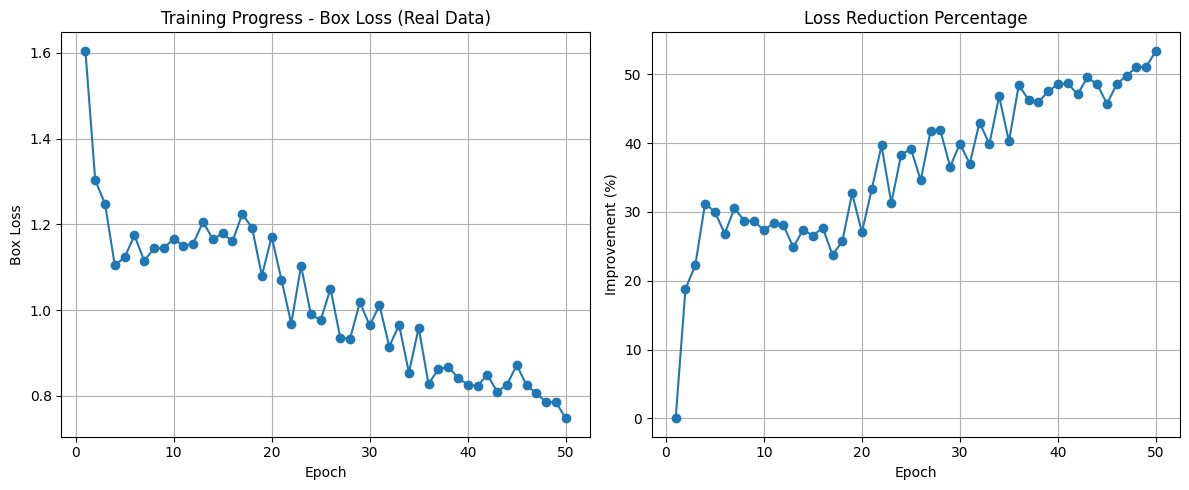

Initial Loss: 1.605
Final Loss: 0.747
Total Improvement: 53.43%


In [30]:
import matplotlib.pyplot as plt

# Epochs
epochs = list(range(1, 51))

# Real box_loss values from your training log
box_loss = [
    1.605, 1.303, 1.248, 1.104, 1.123, 1.174, 1.115, 1.144, 1.145, 1.166,
    1.150, 1.155, 1.206, 1.165, 1.179, 1.160, 1.224, 1.192, 1.080, 1.171,
    1.071, 0.9685, 1.103, 0.9904, 0.9763, 1.050, 0.9356, 0.9333, 1.018, 0.9641,
    1.011, 0.9149, 0.9653, 0.8540, 0.9588, 0.8277, 0.8616, 0.8675, 0.8424, 0.8256,
    0.8231, 0.8493, 0.8096, 0.8257, 0.8713, 0.8253, 0.8056, 0.7858, 0.7851, 0.7474
]

# Create plot
plt.figure(figsize=(12, 5))

# Box Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, box_loss, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Box Loss')
plt.title('Training Progress - Box Loss (Real Data)')
plt.grid(True)

# Improvement %
plt.subplot(1, 2, 2)
improvement = [(box_loss[0] - l) / box_loss[0] * 100 for l in box_loss]
plt.plot(epochs, improvement, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Improvement (%)')
plt.title('Loss Reduction Percentage')
plt.grid(True)

plt.tight_layout()
plt.savefig('real_training_curves.png', dpi=150)
plt.show()

# Summary
print(f"Initial Loss: {box_loss[0]:.3f}")
print(f"Final Loss: {box_loss[-1]:.3f}")
print(f"Total Improvement: {(box_loss[0] - box_loss[-1]) / box_loss[0] * 100:.2f}%")

   Metric  Value   Status
    mAP50  0.614 Moderate
Precision  0.643 Moderate
   Recall  0.638 Moderate


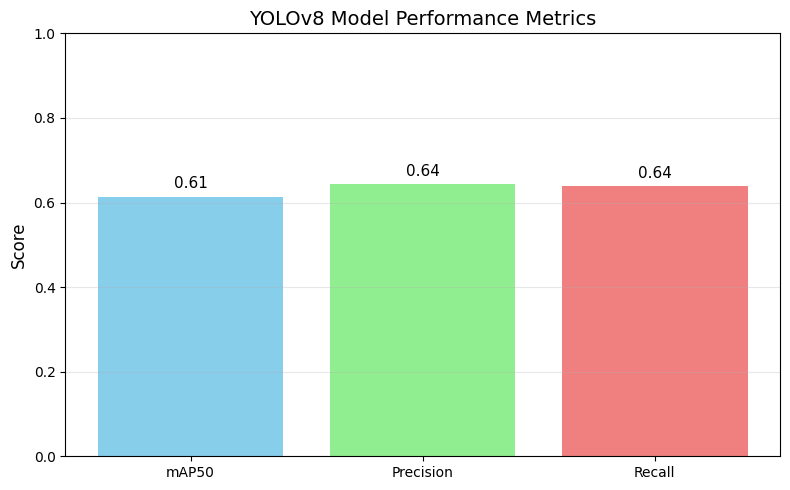

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Results from your YOLOv8 evaluation
results = {
    'Metric': ['mAP50', 'Precision', 'Recall'],
    'Value': [0.614, 0.643, 0.638],
    'Status': ['Moderate', 'Moderate', 'Moderate']
}

# Create DataFrame
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

# Create bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(results['Metric'], results['Value'], color=['skyblue', 'lightgreen', 'lightcoral'])
plt.ylim(0, 1)
plt.ylabel('Score', fontsize=12)
plt.title('YOLOv8 Model Performance Metrics', fontsize=14)

# Add text labels on top of bars
for bar, val in zip(bars, results['Value']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', fontsize=11)

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('performance_metrics.png', dpi=150)
plt.show()

In [22]:
import pandas as pd
from ultralytics import YOLO

# Load model and zone labels
model = YOLO('/content/drive/MyDrive/yolo_runs/construction_84/weights/best.pt')
zone_df = pd.read_csv('/content/drive/MyDrive/My_collect_data/zone_labels.csv')
zone_dict = dict(zip(zone_df['image_name'], zone_df['zone']))

def check_safety(image_path):
    """Check if a worker is safe based on zone rules"""
    img_name = image_path.split('/')[-1]
    zone = zone_dict.get(img_name, 'B')  # Default Zone B

    results = model(image_path)

    persons = 0
    helmets = 0
    vests = 0

    for box in results[0].boxes:
        class_id = int(box.cls[0])
        if class_id == 0:
            persons += 1
        elif class_id == 1:
            helmets += 1
        elif class_id == 2:
            vests += 1

    # Zone-based safety rules
    if zone == 'A':
        # Active Zone: Need helmet AND vest
        if helmets >= persons and vests >= persons:
            status = "✅ SAFE"
            reason = "All workers have helmet and vest"
        else:
            status = "❌ UNSAFE"
            reason = f"Missing: {persons - helmets} helmets, {persons - vests} vests"
    else:
        # Zone B: Need helmet only
        if helmets >= persons:
            status = "✅ SAFE"
            reason = "All workers have helmets"
        else:
            status = "❌ UNSAFE"
            reason = f"Missing: {persons - helmets} helmets"

    return {
        'zone': zone,
        'workers': persons,
        'helmets': helmets,
        'vests': vests,
        'status': status,
        'reason': reason
    }

# Test on uploaded image
for img_name in uploaded.keys():
    result = check_safety(img_name)

    print(f"\n{'='*40}")
    print(f"🏗️ SAFETY REPORT: {img_name}")
    print(f"{'='*40}")
    print(f"📍 Zone: {result['zone']}")
    print(f"👷 Workers detected: {result['workers']}")
    print(f"🪖 Helmets detected: {result['helmets']}")
    print(f"👕 Vests detected: {result['vests']}")
    print(f"\n📋 Status: {result['status']}")
    print(f"📝 Reason: {result['reason']}")


image 1/1 /content/WhatsApp Image 2026-04-01 at 8-46-23 AM (12)_jpeg.rf.YXOjG9xzQibCjGP1BS6q.jpeg: 640x384 2 persons, 1 helmet, 11.4ms
Speed: 1.5ms preprocess, 11.4ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 384)

🏗️ SAFETY REPORT: WhatsApp Image 2026-04-01 at 8-46-23 AM (12)_jpeg.rf.YXOjG9xzQibCjGP1BS6q.jpeg
📍 Zone: B
👷 Workers detected: 2
🪖 Helmets detected: 1
👕 Vests detected: 0

📋 Status: ❌ UNSAFE
📝 Reason: Missing: 1 helmets


In [23]:
import shutil

# Copy model to a safe location
source = '/content/drive/MyDrive/yolo_runs/construction_84/weights/best.pt'
destination = '/content/drive/MyDrive/construction_model_final.pt'

shutil.copy(source, destination)
print(f"✅ Model saved to: {destination}")

# Check file size
import os
size = os.path.getsize(destination) / 1000000
print(f"Model size: {size:.1f} MB")

✅ Model saved to: /content/drive/MyDrive/construction_model_final.pt
Model size: 22.5 MB


In [24]:
from google.colab import files
import pandas as pd
from ultralytics import YOLO
import cv2
from datetime import datetime

# Load model and zone labels
model = YOLO('/content/drive/MyDrive/yolo_runs/construction_84/weights/best.pt')
zone_df = pd.read_csv('/content/drive/MyDrive/My_collect_data/zone_labels.csv')
zone_dict = dict(zip(zone_df['image_name'], zone_df['zone']))

# Your original function
def check_safety(image_path):
    img_name = image_path.split('/')[-1]
    zone = zone_dict.get(img_name, 'B')
    results = model(image_path)

    persons = helmets = vests = 0
    for box in results[0].boxes:
        class_id = int(box.cls[0])
        if class_id == 0: persons += 1
        elif class_id == 1: helmets += 1
        elif class_id == 2: vests += 1

    if zone == 'A':
        if helmets >= persons and vests >= persons:
            status, reason = "✅ SAFE", "All workers have helmet and vest"
        else:
            status, reason = "❌ UNSAFE", f"Missing: {persons-helmets} helmets, {persons-vests} vests"
    else:
        if helmets >= persons:
            status, reason = "✅ SAFE", "All workers have helmets"
        else:
            status, reason = "❌ UNSAFE", f"Missing: {persons-helmets} helmets"

    return {'zone': zone, 'workers': persons, 'helmets': helmets, 'vests': vests, 'status': status, 'reason': reason}

# NEW: Confidence scoring
def get_confidence(image_path):
    results = model(image_path)
    confs = {'person': [], 'helmet': [], 'vest': []}
    for box in results[0].boxes:
        class_id = int(box.cls[0])
        if class_id == 0: confs['person'].append(float(box.conf[0]))
        elif class_id == 1: confs['helmet'].append(float(box.conf[0]))
        elif class_id == 2: confs['vest'].append(float(box.conf[0]))

    avg = {k: sum(v)/len(v) if v else 0 for k, v in confs.items()}
    overall = sum(avg.values())/3
    level = "HIGH ✅" if overall > 0.7 else "MEDIUM ⚠️" if overall > 0.4 else "LOW ❌"
    return avg, overall, level

# NEW: Edge case handling
def get_edge_warnings(image_path):
    img = cv2.imread(image_path)
    h, w = img.shape[:2]
    results = model(image_path)
    warnings = []

    for box in results[0].boxes:
        conf = float(box.conf[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        size_ratio = ((x2-x1)*(y2-y1)) / (w*h)

        if size_ratio < 0.05 and conf < 0.5:
            warnings.append("⚠️ Distant worker - detection may be inaccurate")
        if conf < 0.4 and size_ratio > 0.1:
            warnings.append("⚠️ Possible occlusion - manual review recommended")
    return warnings

# Test
print("📤 Upload an image to test:")
uploaded = files.upload()

for img_name in uploaded.keys():
    print("\n" + "="*60)
    print(f"🔍 ANALYZING: {img_name}")
    print("="*60)

    # Run all checks
    safety = check_safety(img_name)
    avg_conf, overall_conf, conf_level = get_confidence(img_name)
    edge_warnings = get_edge_warnings(img_name)

    # Display results
    print(f"\n📍 ZONE: {safety['zone']}")
    print(f"👷 Workers: {safety['workers']}")
    print(f"🪖 Helmets: {safety['helmets']}")
    print(f"👕 Vests: {safety['vests']}")

    print(f"\n📊 CONFIDENCE: {conf_level}")
    print(f"   Person: {avg_conf['person']:.2%}")
    print(f"   Helmet: {avg_conf['helmet']:.2%}")
    print(f"   Vest: {avg_conf['vest']:.2%}")

    if edge_warnings:
        print(f"\n⚠️ EDGE CASE WARNINGS:")
        for w in edge_warnings:
            print(f"   {w}")

    print(f"\n📋 STATUS: {safety['status']}")
    print(f"📝 REASON: {safety['reason']}")

    # Save report
    report_file = f"report_{img_name.replace('.jpg','.txt')}"
    with open(report_file, 'w') as f:
        f.write(f"Image: {img_name}\nZone: {safety['zone']}\nStatus: {safety['status']}\nReason: {safety['reason']}\nConfidence: {conf_level}")
    print(f"\n📄 Report saved: {report_file}")

📤 Upload an image to test:


Saving WhatsApp Image 2026-04-01 at 8-46-23 AM_jpeg.rf.uZ1zhinqe6nxHPSCrc2U.jpeg to WhatsApp Image 2026-04-01 at 8-46-23 AM_jpeg.rf.uZ1zhinqe6nxHPSCrc2U.jpeg

🔍 ANALYZING: WhatsApp Image 2026-04-01 at 8-46-23 AM_jpeg.rf.uZ1zhinqe6nxHPSCrc2U.jpeg

image 1/1 /content/WhatsApp Image 2026-04-01 at 8-46-23 AM_jpeg.rf.uZ1zhinqe6nxHPSCrc2U.jpeg: 640x480 6 persons, 4 helmets, 2 vests, 50.0ms
Speed: 2.3ms preprocess, 50.0ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /content/WhatsApp Image 2026-04-01 at 8-46-23 AM_jpeg.rf.uZ1zhinqe6nxHPSCrc2U.jpeg: 640x480 6 persons, 4 helmets, 2 vests, 12.0ms
Speed: 2.5ms preprocess, 12.0ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /content/WhatsApp Image 2026-04-01 at 8-46-23 AM_jpeg.rf.uZ1zhinqe6nxHPSCrc2U.jpeg: 640x480 6 persons, 4 helmets, 2 vests, 12.0ms
Speed: 2.5ms preprocess, 12.0ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 480)

📍 ZONE: A
👷 Workers: 6
🪖 Helmets: 4
👕 V

📤 Upload an image to test:


Saving WhatsApp Image 2026-04-01 at 8.46.23 AM (9).jpeg to WhatsApp Image 2026-04-01 at 8.46.23 AM (9).jpeg

🔍 ANALYZING: WhatsApp Image 2026-04-01 at 8.46.23 AM (9).jpeg

image 1/1 /content/WhatsApp Image 2026-04-01 at 8.46.23 AM (9).jpeg: 640x480 8 persons, 6 helmets, 1 vest, 12.7ms
Speed: 2.0ms preprocess, 12.7ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)

🖼️ IMAGE WITH DETECTIONS:


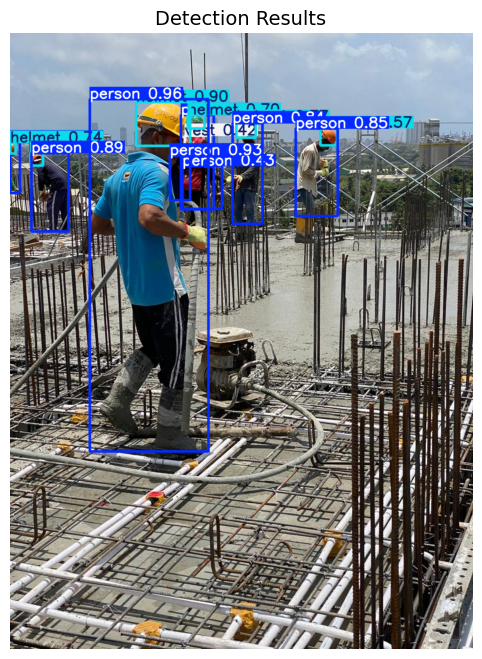


📍 ZONE: B
👷 Workers: 8
🪖 Helmets: 6
👕 Vests: 1

📊 CONFIDENCE: MEDIUM ⚠️
   Person: 70.77%
   Helmet: 74.93%
   Vest: 41.96%

⚠️ EDGE CASE WARNINGS:
   ⚠️ Distant worker - detection may be inaccurate
   ⚠️ Distant worker - detection may be inaccurate
   ⚠️ Distant worker - detection may be inaccurate
   ⚠️ Distant worker - detection may be inaccurate

📋 STATUS: ❌ UNSAFE
📝 REASON: Missing: 2 helmets

📄 Report saved: report_WhatsApp Image 2026-04-01 at 8.46.23 AM (9).txt
🖼️ Image saved: output_WhatsApp Image 2026-04-01 at 8.46.23 AM (9).jpeg


In [27]:
from google.colab import files
import pandas as pd
from ultralytics import YOLO
import cv2
from datetime import datetime
import matplotlib.pyplot as plt

# Load model and zone labels
model = YOLO('/content/drive/MyDrive/yolo_runs/construction_84/weights/best.pt')
zone_df = pd.read_csv('/content/drive/MyDrive/My_collect_data/zone_labels.csv')
zone_dict = dict(zip(zone_df['image_name'], zone_df['zone']))

def check_safety(image_path):
    img_name = image_path.split('/')[-1]
    zone = zone_dict.get(img_name, 'B')
    results = model(image_path)

    persons = helmets = vests = 0
    for box in results[0].boxes:
        class_id = int(box.cls[0])
        if class_id == 0: persons += 1
        elif class_id == 1: helmets += 1
        elif class_id == 2: vests += 1

    if zone == 'A':
        if helmets >= persons and vests >= persons:
            status, reason = "✅ SAFE", "All workers have helmet and vest"
        else:
            status, reason = "❌ UNSAFE", f"Missing: {persons-helmets} helmets, {persons-vests} vests"
    else:
        if helmets >= persons:
            status, reason = "✅ SAFE", "All workers have helmets"
        else:
            status, reason = "❌ UNSAFE", f"Missing: {persons-helmets} helmets"

    return results, {'zone': zone, 'workers': persons, 'helmets': helmets, 'vests': vests, 'status': status, 'reason': reason}

def get_confidence(results):
    confs = {'person': [], 'helmet': [], 'vest': []}
    for box in results[0].boxes:
        class_id = int(box.cls[0])
        if class_id == 0: confs['person'].append(float(box.conf[0]))
        elif class_id == 1: confs['helmet'].append(float(box.conf[0]))
        elif class_id == 2: confs['vest'].append(float(box.conf[0]))

    avg = {k: sum(v)/len(v) if v else 0 for k, v in confs.items()}
    overall = sum(avg.values())/3
    level = "HIGH ✅" if overall > 0.7 else "MEDIUM ⚠️" if overall > 0.4 else "LOW ❌"
    return avg, overall, level

def get_edge_warnings(results, image_path):
    img = cv2.imread(image_path)
    h, w = img.shape[:2]
    warnings = []

    for box in results[0].boxes:
        conf = float(box.conf[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        size_ratio = ((x2-x1)*(y2-y1)) / (w*h)

        if size_ratio < 0.05 and conf < 0.5:
            warnings.append("⚠️ Distant worker - detection may be inaccurate")
        if conf < 0.4 and size_ratio > 0.1:
            warnings.append("⚠️ Possible occlusion - manual review recommended")
    return warnings

def display_image_with_boxes(results, image_path):
    """Display the image with detection boxes"""
    # Get annotated image
    annotated_img = results[0].plot()
    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

    # Display
    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_img_rgb)
    plt.axis('off')
    plt.title('Detection Results', fontsize=14)
    plt.show()

    return annotated_img

# Test
print("📤 Upload an image to test:")
uploaded = files.upload()

for img_name in uploaded.keys():
    print("\n" + "="*60)
    print(f"🔍 ANALYZING: {img_name}")
    print("="*60)

    # Run all checks
    results, safety = check_safety(img_name)
    avg_conf, overall_conf, conf_level = get_confidence(results)
    edge_warnings = get_edge_warnings(results, img_name)

    # Display image with boxes
    print("\n🖼️ IMAGE WITH DETECTIONS:")
    display_image_with_boxes(results, img_name)

    # Display results
    print(f"\n📍 ZONE: {safety['zone']}")
    print(f"👷 Workers: {safety['workers']}")
    print(f"🪖 Helmets: {safety['helmets']}")
    print(f"👕 Vests: {safety['vests']}")

    print(f"\n📊 CONFIDENCE: {conf_level}")
    print(f"   Person: {avg_conf['person']:.2%}")
    print(f"   Helmet: {avg_conf['helmet']:.2%}")
    print(f"   Vest: {avg_conf['vest']:.2%}")

    if edge_warnings:
        print(f"\n⚠️ EDGE CASE WARNINGS:")
        for w in edge_warnings:
            print(f"   {w}")

    print(f"\n📋 STATUS: {safety['status']}")
    print(f"📝 REASON: {safety['reason']}")

    # Save report
    report_file = f"report_{img_name.replace('.jpg','.txt').replace('.jpeg','.txt')}"
    with open(report_file, 'w') as f:
        f.write(f"Image: {img_name}\n")
        f.write(f"Zone: {safety['zone']}\n")
        f.write(f"Workers: {safety['workers']}\n")
        f.write(f"Helmets: {safety['helmets']}\n")
        f.write(f"Vests: {safety['vests']}\n")
        f.write(f"Status: {safety['status']}\n")
        f.write(f"Reason: {safety['reason']}\n")
        f.write(f"Confidence: {conf_level}\n")
        f.write(f"Person Confidence: {avg_conf['person']:.2%}\n")
        f.write(f"Helmet Confidence: {avg_conf['helmet']:.2%}\n")
        f.write(f"Vest Confidence: {avg_conf['vest']:.2%}\n")

    print(f"\n📄 Report saved: {report_file}")

    # Save annotated image
    output_img = f"output_{img_name}"
    annotated_img = results[0].plot()
    cv2.imwrite(output_img, annotated_img)
    print(f"🖼️ Image saved: {output_img}")